In [1]:
# plot gradient of cross logit loss with respect to input
# for a given input and target
import numpy as np
import torch
import matplotlib.pyplot as plt
import scienceplots

In [2]:
def ce_deriv(x):
    # binary cross entropy derivative
    return -1 / (1 + np.exp(x))

def ce(x):
    # binary cross entropy
    return np.log(1 + np.exp(-x))

In [3]:
from penex.losses import PENEX

ValueError: x and y must have same first dimension, but have shapes (1000,) and (1,)

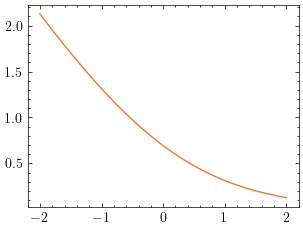

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

x_grid = np.linspace(-2, 2, 1000)
alpha = [0.05, 0.1, 0.2]

# Style settings
plt.style.use(["science", "vibrant"])

#plt.rcParams['font.family'] = 'serif'
#plt.rcParams['font.serif'] = ['Computer Modern Roman']

matplotlib.rcParams['text.usetex'] = True
#matplotlib.rcParams['text.latex.preamble'] = r'\usepackage[utopia]{mathdesign}'


plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.fancybox'] = True  # Force fancybox
#plt.rcParams['legend.edgecolor'] = 'black'  # Optional: add visible border


fig, ax = plt.subplots()

# Plot CE line
line_ce, = ax.plot(x_grid, ce(x_grid),
                   label=r'$\mathcal{L}_{\mathrm{CE}}(f^{(1)}(x))$')

# Plot PENEX lines, each alpha gets a different color automatically
penex_lines = []
for a in alpha:
    penex = PENEX(sensitivity=a, penalty_mode="auto")
    logits = torch.stack([torch.zeros_like(torch.tensor(x_grid)), torch.tensor(x_grid)], dim=1)
    targets = torch.ones(len(x_grid), dtype=torch.long)
    penex_values = penex(logits, targets)
    line_penex, = ax.plot(x_grid, penex(logits, targets).numpy(),
                          label=rf'$\alpha={a}$')
    penex_lines.append(line_penex)

# First legend: CE
legend_ce = ax.legend(handles=[line_ce], 
                      labels=[r'$\mathcal{L}_{\mathrm{CE}}(f^{(1)}(x))$'],
                      fancybox=True, framealpha=0.3, loc='upper left')
ax.add_artist(legend_ce)  # Make sure the CE legend stays visible

# Second legend: PENEX lines
legend_penex = ax.legend(handles=penex_lines,
                         # Each line has a label like alpha=0.05, etc.
                         title=r'$\alpha^{-1}\,\mathcal{L}_{\mathrm{PENEX}}(f^{(1)}(x); \alpha)$',
                         fancybox=True, framealpha=0.3,
                         loc='lower right')

# Axis labels, grid, etc.
ax.set_xlabel(r'$f^{(1)}(x)$')
ax.set_ylabel(r'$\frac{\partial}{\partial f^{(1)}(x)}$')
ax.grid(True)
fig.tight_layout()

fig.patch.set_alpha(0.0)  # Transparent figure background
ax.patch.set_alpha(0.0)   # Transparent axes background

"""# Turn everything white
for spine in ax.spines.values():
    spine.set_color('white')

ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.tick_params(colors='white')

# Legend text and title
if legend_ce:
    plt.setp(legend_ce.get_texts(), color='white')
    legend_ce.get_title().set_color('white')

if legend_penex:
    plt.setp(legend_penex.get_texts(), color='white')
    legend_penex.get_title().set_color('white')

# Set lines to white (optional, if not already colorful)
for line in ax.get_lines():s
    line.set_color('white')

ax.title.set_color('white')"""

plt.savefig('plots/penex_deriv.pdf')


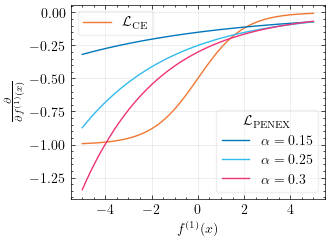

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib

x_grid = np.linspace(-5, 5, 10000)
alpha = [0.15, 0.25, 0.3]

# Style settings
plt.style.use(["science", "vibrant"])
matplotlib.rcParams['text.usetex'] = True
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.fancybox'] = True

fig, ax = plt.subplots()

# Plot CE derivative
line_ce, = ax.plot(x_grid, ce_deriv(x_grid),  # Use derivative function
                   label=r'$\frac{\partial\mathcal{L}_{\mathrm{CE}}}{\partial f^{(1)}(x)}$')

# Plot PENEX derivatives
penex_lines = []
for a in alpha:
    penex = PENEX(sensitivity=a, penalty_mode="auto")
    
    # Compute PENEX gradients
    gradients = []
    for i in range(len(x_grid)):
        x_single = torch.tensor([x_grid[i]], requires_grad=True, dtype=torch.float32)
        logits_single = torch.stack([torch.zeros_like(x_single), x_single], dim=1)
        targets_single = torch.ones(1, dtype=torch.long)
        
        loss = penex(logits_single, targets_single)
        loss.backward()
        gradients.append(x_single.grad.item())
    
    gradients = np.array(gradients)  # No scaling this time
    
    line_penex, = ax.plot(x_grid, gradients, label=rf'$\alpha={a}$')
    penex_lines.append(line_penex)

# First legend: CE
legend_ce = ax.legend(handles=[line_ce], 
                      labels=[r'$\mathcal{L}_{\mathrm{CE}}$'],
                      fancybox=True, framealpha=0.3, loc='upper left')
ax.add_artist(legend_ce)

# Second legend: PENEX lines
legend_penex = ax.legend(handles=penex_lines,
                         title=r'$\mathcal{L}_{\mathrm{PENEX}}$',
                         fancybox=True, framealpha=0.3,
                         loc='lower right')

# Axis labels
ax.set_xlabel(r'$f^{(1)}(x)$')
ax.set_ylabel(r'$\frac{\partial}{\partial f^{(1)}(x)}$')
ax.grid(True, alpha=0.3)
fig.tight_layout()

plt.savefig('plots/penex_gradients.pdf', dpi=300, bbox_inches='tight')
plt.show()